# Implicit Solvent Sample-Based Quantum Diagonalization

*Usage estimate: 10 seconds on ibm_torino*

Based on [*Implicit Solvent Sample-Based Quantum Diagonalization* - J. Phys. Chem. B 2023, 127 (21), 4471–4482.](https://pubs.acs.org/doi/10.1021/acs.jpcb.5c01030)

The recent work, $\textit{Implicit Solvent Sample-Based Quantum Diagonalization}$, directly addressed the question: “Can Sample-Based Quantum Diagonalization energy calculations be reliably integrated with established classical solvation models to reproduce the outcomes of classical energy computations for the simplest biologically relevant polar molecules?” 
But a pressing question yet to be answered within scientific literature is "Within the solute-solvent computational context, can SQD add value beyond the established classical routines?" 

*This notebook was adapted from IBM Quantum's Road to Practitioner program, Feb-May 2026*


In [2]:
import pyscf
from pyscf import gto   # Deals with molecular initialization
from pyscf import scf   # Solvation methods
from pyscf import mcscf # More computational solvation methods
from pyscf.solvent import pcm
from qiskit_ibm_catalog import QiskitFunction, QiskitServerless
from qiskit_ibm_runtime import QiskitRuntimeService

## Methylamine - Restricted Hartree-Fock

### Initialize the molecule object by using known $\textit{a priori}$ molecular geometry

In [ ]:
# Molecular geometries retrieved from:

molecule_name = 'Methylamine'

methylamine_geo = """
N -0.7154 0.0000 0.0000
C 0.7154 0.0000 0.0000
H 1.1069 0.0916 1.0174
H 1.0996 0.8349 -0.5930
H 1.0996 -0.9274 -0.4345
H -1.0625 0.8564 0.4294
H -1.0625 -0.7661 0.5753
"""

In [ ]:
# Explicitly definine the molecule
mol = gto.M()
mol.atom = methylamine_geo
mol.basis = "cc-pVDZ"
mol.unit = "Angstrom"
mol.charge = 0
mol.spin = 0
mol.verbose = 4

mol.build()

### Define solvation effects by using the polarizable continuum model (PCM)

In [ ]:
# Dielectric parameters retrieved from: https://gaussian.com/scrf/

eps_water = 78.3553

In [ ]:
cm = pcm.PCM(mol)
cm.eps = eps_water
cm.method = "IEF-PCM"

In [ ]:
from pyscf import scf   # Self-Consistent Field methods

mf_pcm0 = scf.RHF(mol).PCM(cm) 

### Geometry optimization by using TRIC

In [ ]:
# Geometry optimization with geomeTRIC
from pyscf.geomopt.geometric_solver import optimize 
mol_opt = optimize(mf_pcm0, tol_grad=3e-4, verbose=0) 

geometric-optimize called with the following command line:
/opt/anaconda3/envs/capstone_env/lib/python3.13/site-packages/ipykernel_launcher.py --f=/Users/courtneybrown/Library/Jupyter/runtime/kernel-v30e74083f60cd0a544f8f85475d3717cf1a26e2e7.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%

### Compute the restricted Hartree-Fock energy


In [11]:
# Run the kernel to get the RHF energy
mf_opt = scf.RHF(mol_opt).PCM(cm)
hf_e = float(mf_opt.kernel())

In [11]:
print(f"Restricted Hartree-Fock Energy: {hf_e}")

Restricted Hartree-Fock Energy: -95.2277952024392


## Methylamine CASCI/(cc-pVDZ) IEF-PCM (by using Qiskit Serverless)


In [12]:
# Establish Qiskit Runtime connection
client = QiskitServerless(name="r2p-2026")

In [ ]:
# Share the program intended to run in the cloud environment (re-upload it any time source code is changed)
client.upload(
    QiskitFunction(
        title="classical_simulation",
        entrypoint="classical_simulation.py",
        working_dir="source_files"))

QiskitFunction(classical_simulation)

In [15]:
# Setup a Serverless Client
worker = client.load("classical_simulation")

In [ ]:
from json.encoder import JSONEncoder

ao_labels = ['C 2s', 'C 2p', 'N 2s', 'N 2p', 'H 1s']
data_e = JSONEncoder().encode([mol_opt.tostring(), eps_water, ao_labels])

In [17]:
serverless_job = worker.run(data=data_e)

In [ ]:
from utils.helpers import feedback_serverless

_ = feedback_serverless(serverless_job)

>>>>> Serverless status: 2b5f7837-258f-413b-9661-1de921003abe
>>>>> [0s] Serverless job 2b5f7837-258f-413b-9661-1de921003abe:                 QUEUED
>>>>> [10s] Serverless job 2b5f7837-258f-413b-9661-1de921003abe:                 QUEUED
>>>>> [20s] Serverless job 2b5f7837-258f-413b-9661-1de921003abe:                 RUNNING
>>>>> [30s] Serverless job 2b5f7837-258f-413b-9661-1de921003abe:                 RUNNING
>>>>> [40s] Serverless job 2b5f7837-258f-413b-9661-1de921003abe:                 RUNNING
>>>>> [50s] Serverless job 2b5f7837-258f-413b-9661-1de921003abe:                 RUNNING
>>>>> [60s] Serverless job 2b5f7837-258f-413b-9661-1de921003abe:                 DONE
>>>>> Serverless job 2b5f7837-258f-413b-9661-1de921003abe: DONE


In [19]:
from json.decoder import JSONDecoder
CASCI_E = JSONDecoder().decode(serverless_job.result()['outputs'])[0]

In [ ]:
# Get the approximated classical baseline for Methylamine
print(f"CASCI/IEF-PCM(cc-pVDZ): E={CASCI_E}")

CASCI/IEF-PCM(cc-pVDZ): E=-95.35035523972208


## Methylamine SQD/(cc-pVDZ) IEF-PCM (by using Qiskit Serverless)

### Establish a Qiskit Runtime connection

In [ ]:
# Establish Quantum Resource connection

service = QiskitRuntimeService(name="r2p-2026")

backend_name = "ibm_boston"
backend = service.backend(backend_name, use_fractional_gates=True)
print(f"Using backend {backend.name}")

Using backend ibm_boston


### Establish a Qiskit Serverless connection 

In [ ]:
# Establish Classical HPC Resource connection (only if not done for classical baseline calculation)

client = QiskitServerless(name="r2p-2026" )

In [ ]:
from pyscf.mcscf import avas

# Re-define the PCM
cm = pcm.PCM(mol_opt)
cm.eps = eps_water 
cm.method = "IEF-PCM"

# Re-build the Restricted Hartree Fock object
mf_opt = scf.RHF(mol_opt).PCM(cm)
mf_opt.kernel(verbose=0)

# Run AVAS
ao_labels = ['C 2s', 'C 2p', 'N 2s', 'N 2p', 'H 1s']
avas_ = avas.AVAS(mf_opt, ao_labels, with_iao=True, canonicalize=True, verbose=0)
avas_.kernel()
norb, ne_act, mo_avas = avas_.ncas, avas_.nelecas, avas_.mo_coeff

num_elec_a = (ne_act + mol_opt.spin) // 2
num_elec_b = (ne_act - mol_opt.spin) // 2

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager
import ffsim

from utils.sqd_helpers import get_zigzag_physical_layout

# Initial LUCJ ansatz layout
initial_layout, _ = get_zigzag_physical_layout(norb, backend=backend)

# Initialize a pass manager
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, initial_layout=initial_layout, basis_gates=['cz', 'id', 'rz', 'sx', 'x']
)

pass_manager.pre_init = ffsim.qiskit.PRE_INIT

In [ ]:
client.upload(
    QiskitFunction(
        title="diagonalization_engine",
        entrypoint="diagonalization_engine.py",

QiskitFunction(diagonalization_engine)

>>>>> ACTIVE SPACE CALCULATIONS 
Parsing as_fcidump_09:45:43.txt
converged SCF energy = -95.2224014052199
>>>>> RUNNING CCSD
E(CCSD) = -95.34417352803314  E_corr = -0.1217721228132089


Overwritten attributes  get_hcore get_ovlp  of <class 'pyscf.scf.hf_symm.SymAdaptedRHF'>
Pass: Decompose - 3.23510 (ms)Pass: MergeOrbitalRotations - 1.26719 (ms)Pass: UnitarySynthesis - 0.07081 (ms)Pass: HighLevelSynthesis - 10.68115 (ms)Pass: BasisTranslator - 1.22428 (ms)Pass: ElidePermutations - 0.26107 (ms)Pass: RemoveDiagonalGatesBeforeMeasure - 0.09394 (ms)Pass: RemoveIdentityEquivalent - 0.19884 (ms)Pass: InverseCancellation - 0.09418 (ms)Pass: ContractIdleWiresInControlFlow - 0.00477 (ms)Pass: CommutativeCancellation - 0.60177 (ms)Pass: ConsolidateBlocks - 2.75898 (ms)Pass: Split2QUnitaries - 0.09012 (ms)Pass: SetLayout - 0.04411 (ms)Pass: FullAncillaAllocation - 0.51403 (ms)Pass: EnlargeWithAncilla - 0.30375 (ms)Pass: ApplyLayout - 0.81015 (ms)Pass: CheckMap - 0.97680 (ms)Pass: BarrierBeforeFinalMeasurements - 0.82994 (ms)Pass: SabreSwap - 5.22280 (ms)Pass: FilterOpNodes - 0.50616 (ms)Pass: UnitarySynthesis - 0.02909 (ms)Pass: HighLevelSynthesis - 0.11396 (ms)

>>>>> UPDATED t1, t2 PARAMETERS
>>>>> CONSTRUCTING LUCJ CIRCUIT


Pass: BasisTranslator - 10.71310 (ms)Pass: Depth - 0.98825 (ms)Pass: Size - 0.07701 (ms)Pass: MinimumPoint - 0.01407 (ms)Pass: ConsolidateBlocks - 67.45410 (ms)Pass: UnitarySynthesis - 16.20507 (ms)Pass: RemoveIdentityEquivalent - 0.24080 (ms)Pass: Optimize1qGatesDecomposition - 2.55108 (ms)Pass: CommutativeCancellation - 2.48504 (ms)Pass: ContractIdleWiresInControlFlow - 0.00405 (ms)Pass: GatesInBasis - 0.54312 (ms)Pass: Depth - 0.77581 (ms)Pass: Size - 0.00691 (ms)Pass: MinimumPoint - 0.35405 (ms)Pass: ConsolidateBlocks - 3.26300 (ms)Pass: UnitarySynthesis - 1.50490 (ms)Pass: RemoveIdentityEquivalent - 0.18215 (ms)Pass: Optimize1qGatesDecomposition - 1.37234 (ms)Pass: CommutativeCancellation - 2.78306 (ms)Pass: ContractIdleWiresInControlFlow - 0.00811 (ms)Pass: GatesInBasis - 0.98920 (ms)Pass: Depth - 0.46802 (ms)Pass: Size - 0.00381 (ms)Pass: MinimumPoint - 0.84901 (ms)Pass: ConsolidateBlocks - 2.91991 (ms)Pass: UnitarySynthesis - 2.23088 (ms)Pass: RemoveIdentityEquivalent - 0.41485

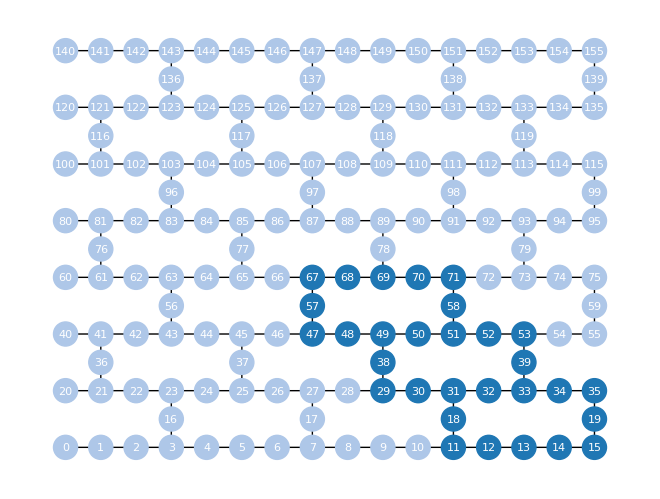

In [ ]:
# Sanity Check a Representative Layout
from pyscf import ao2mo
from utils.heartwood import run_active_space_calculation, get_lucj
from utils.visualization import used_qubits, color_batches
from utils.gate_map import plot_gate_map

mc = pyscf.mcscf.CASCI(mf_opt, ncas=norb, nelecas=ne_act).PCM(cm)
mc.with_solvent.method = mf_opt.with_solvent.method  
mc.with_solvent.eps = mf_opt.with_solvent.eps 
mc.mo_coeff = mo_avas.copy() 

h1e_cas, ecore = mc.get_h1eff() 
h2e_cas = ao2mo.restore(1, mc.get_h2eff(), norb) 

mc.mo_coeff, t1, t2 = run_active_space_calculation(h1e_cas, h2e_cas, norb, ne_act, mo_avas.copy(), mf_opt.mol.nelectron//2, ecore)
circuit = get_lucj(norb, num_elec_a, num_elec_b, t1, t2, n_reps=1)
isa_circuit = pass_manager.run(circuit)

qubits = used_qubits(isa_circuit, include={"unitary"})
qcolors = color_batches([set(qubits), set(qubits)^set(range(0, backend.configuration().n_qubits))])
plot_gate_map(backend, label_qubits=True, qubit_color=qcolors, line_color=["black" for _ in backend.coupling_map.get_edges()])

### User controls 
Systematically vary these parameters to improve hardware results.


In [ ]:

use_hardware = True

# Transpiler Options
optimization_level = 3

# Heartwood Algorithm Options
n_iter = 10 
resample = 2 
shots = 10000 

# SQD Options
energy_tol = 1e-4
occupancies_tol = 1e-3 
max_iterations = 100

# Eigenstate Solver Options
num_batches = 5
samples_per_batch = 2000
carryover_threshold = 0.5
symmetrize_spin = True
max_cycle = 20

# Classical Post-Processing Options
mem = 32

In [ ]:
# from qiskit_aer import AerSimulator
# fake_backend=AerSimulator.from_backend(backend)
# fake_backend.set_options(method='matrix_product_state')

In [ ]:
# The Heartwood Algorithm
import time
import numpy as np

from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
from qiskit_addon_sqd.counts import generate_bit_array_uniform
from pyscf import ao2mo

from utils.heartwood import run_active_space_calculation, update_rdm, get_lucj, classically_diagonalize

# Sampler Primitive Options 
with Session(backend=backend) as session:

    sampler = Sampler(mode=session)
    sampler.options.max_execution_time = 30 

    # Error suppression techniques
    sampler.options.dynamical_decoupling.enable = False
    sampler.options.dynamical_decoupling.sequence_type = 'XY4'
    sampler.options.twirling.enable_measure = True
    sampler.options.twirling.enable_gates = False
    sampler.options.twirling.num_randomizations = 10
    sampler.options.twirling.shots_per_randomization = 1000

    with_solvent_e, with_solvent_v = None, None # Don't touch
    data = []
    for iiter in range(n_iter):
        print(f">>>>> IMPLICIT SOLVENT ITERATION {iiter+1}/{n_iter}")
        if with_solvent_v is not None: 
            mc.get_hcore = lambda *args: mc._scf.get_hcore() + with_solvent_v
        else: 
            mc.get_hcore = lambda *args: mc._scf.get_hcore() 

        h1e_cas, ecore = mc.get_h1eff() 
        h2e_cas = ao2mo.restore(1, mc.get_h2eff(), norb)

        mc.mo_coeff, t1, t2 = run_active_space_calculation(h1e_cas, 
                                                            h2e_cas, 
                                                            norb, 
                                                            ne_act, 
                                                            mo_avas.copy(), 
                                                            mf_opt.mol.nelectron//2, 
                                                            ecore)

        if use_hardware == True:
            if iiter % resample == 0: 
                print(">>>>> GENERATING BITSTRINGS USING QUANTUM HARDWARE")

                circuit = get_lucj(norb, num_elec_a, num_elec_b, t1, t2, n_reps=1)

                print(f">>>>> TRANSPILING LUCJ TO {backend.name}")
                isa_circuit = pass_manager.run(circuit)
                print(f">>>>> SUBMITTING ISA_CIRCUIT TO {backend.name}")
                job = sampler.run([isa_circuit], shots=shots) 
                job_id = str(job.job_id())
                print(f"Job ID: {job_id}")

                timer = 0
                while job.status() != "DONE":
                    timer+=10
                    print(f">>>>> [{timer}s] RUNTIME JOB {job_id}: {job.status()}")
                    time.sleep(10)

                primitive_result = job.result()
                print(f">>>>> RETRIEVED {job_id} FROM {backend.name}")

                pub_result = primitive_result[0]
                bit_array = pub_result.data.meas

        else:
            print(">>>>> GENERATING BITSTRINGS CLASSICALLY")
            rng = np.random.default_rng(24)
            bit_array = generate_bit_array_uniform(100_000, 2*norb, rand_seed=rng) 
            job_id = float("nan") 

        result = classically_diagonalize(bit_array=bit_array, 
                                        nuclear_repulsion_energy=ecore,           # Electronic energy from the core orbitals
                                        hcore=h1e_cas,                            # 1-electron hamiltonian integrals
                                        eri=h2e_cas,                              # 2-electron hamiltonian integrals
                                        num_orbitals=norb,                        # Number of spatial orbitals
                                        nelec=ne_act,                             # Number of electrons
                                        num_elec_a=ne_act//2,                     # Alpha orbitals
                                        num_elec_b=ne_act//2,                     # Beta orbitals
                                        job_id=job_id,                            # QPU bitstring Job ID
                                        client=client,                            # Diagonalization engine worker
                                        energy_tol=energy_tol,                    # SQD option
                                        occupancies_tol=occupancies_tol,          # SQD option
                                        max_iterations=max_iterations,            # SQD option
                                        num_batches=num_batches,                  # Eigenstate solver option
                                        samples_per_batch=samples_per_batch,      # Eigenstate solver option
                                        symmetrize_spin=symmetrize_spin,          # Eigenstate solver option
                                        carryover_threshold=carryover_threshold,  # Eigenstate solver option
                                        max_cycle=max_cycle,                      # Eigenstate solver option
                                        mem=mem,                                  # Memory per Worker (Gb)
                                        )

        e, rdm1 = result[0], result[1]
        rho_approximation = update_rdm(mc, rdm1).copy() 

        if with_solvent_e is not None:
            edup = np.einsum('ij,ji->', with_solvent_v, rho_approximation) 
            e += ecore + with_solvent_e - edup

        else:
            e += ecore 

        # Outputs:
        # with_solvent_e : scalar energy correction due to solvent polarization
        # with_solvent_v : Fock-like matrix to be added to the core Hamiltonian in SCF
        with_solvent_e, with_solvent_v = mc.with_solvent._get_vind(rho_approximation)
        data.append((iiter, float(e), job_id))
        print(f">>>>> END IITER {iiter}")
        print(f">>>>> TOTAL ENERGY: {e}\n")

>>>>> IMPLICIT SOLVENT ITERATION 1/10
>>>>> ACTIVE SPACE CALCULATIONS 
Parsing as_fcidump_09:51:31.txt
converged SCF energy = -95.2212455725437
>>>>> RUNNING CCSD
E(CCSD) = -95.34342268065882  E_corr = -0.1221771081151152


Pass: Decompose - 1.11723 (ms)Pass: MergeOrbitalRotations - 0.63992 (ms)Pass: UnitarySynthesis - 0.05603 (ms)Pass: HighLevelSynthesis - 8.07428 (ms)Pass: BasisTranslator - 0.25582 (ms)Pass: ElidePermutations - 0.01717 (ms)Pass: RemoveDiagonalGatesBeforeMeasure - 0.05794 (ms)Pass: RemoveIdentityEquivalent - 0.12374 (ms)Pass: InverseCancellation - 0.08082 (ms)Pass: ContractIdleWiresInControlFlow - 0.00572 (ms)Pass: CommutativeCancellation - 0.39506 (ms)Pass: ConsolidateBlocks - 2.29502 (ms)Pass: Split2QUnitaries - 0.01478 (ms)Pass: SetLayout - 0.05674 (ms)Pass: FullAncillaAllocation - 0.37193 (ms)Pass: EnlargeWithAncilla - 0.10419 (ms)Pass: ApplyLayout - 0.69809 (ms)Pass: CheckMap - 0.19097 (ms)Pass: BarrierBeforeFinalMeasurements - 0.51713 (ms)Pass: SabreSwap - 2.72799 (ms)Pass: FilterOpNodes - 0.33092 (ms)Pass: UnitarySynthesis - 0.01216 (ms)Pass: HighLevelSynthesis - 0.07915 (ms)Pass: BasisTranslator - 6.98876 (ms)Pass: Depth - 1.39022 (ms)Pass: Size - 0.01097 (ms)

>>>>> UPDATED t1, t2 PARAMETERS
>>>>> GENERATING BITSTRINGS USING QUANTUM HARDWARE
>>>>> CONSTRUCTING LUCJ CIRCUIT
>>>>> TRANSPILING LUCJ TO ibm_boston


Pass: MinimumPoint - 0.03791 (ms)Pass: ConsolidateBlocks - 7.96270 (ms)Pass: UnitarySynthesis - 16.47425 (ms)Pass: RemoveIdentityEquivalent - 0.27704 (ms)Pass: Optimize1qGatesDecomposition - 2.33412 (ms)Pass: CommutativeCancellation - 2.66290 (ms)Pass: ContractIdleWiresInControlFlow - 0.00429 (ms)Pass: GatesInBasis - 0.48375 (ms)Pass: Depth - 0.47684 (ms)Pass: Size - 0.00596 (ms)Pass: MinimumPoint - 0.37599 (ms)Pass: ConsolidateBlocks - 5.73492 (ms)Pass: UnitarySynthesis - 2.10404 (ms)Pass: RemoveIdentityEquivalent - 0.19908 (ms)Pass: Optimize1qGatesDecomposition - 1.37591 (ms)Pass: CommutativeCancellation - 2.05016 (ms)Pass: ContractIdleWiresInControlFlow - 0.00620 (ms)Pass: GatesInBasis - 0.79989 (ms)Pass: Depth - 0.55599 (ms)Pass: Size - 0.00715 (ms)Pass: MinimumPoint - 1.07193 (ms)Pass: ConsolidateBlocks - 3.21794 (ms)Pass: UnitarySynthesis - 1.46365 (ms)Pass: RemoveIdentityEquivalent - 0.19503 (ms)Pass: Optimize1qGatesDecomposition - 1.43194 (ms)Pass: CommutativeCancellation - 3.0

>>>>> SUBMITTING ISA_CIRCUIT TO ibm_boston
Job ID: d7o6e12k4prs73dt3f90
>>>>> [10s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [20s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [30s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [40s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [50s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [60s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [70s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [80s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [90s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [100s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [110s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [120s] RUNTIME JOB d7o6e12k4prs73dt3f90: QUEUED
>>>>> [130s] RUNTIME JOB d7o6e12k4prs73dt3f90: RUNNING
>>>>> RETRIEVED d7o6e12k4prs73dt3f90 FROM ibm_boston
>>>>> STARTING DIAGONALIZATION ENGINE 
>>>>> SQD ITERATION 1
>>>>> SUBSAMPLE 0
>>>>> 	ENERGY: -95.3397290419206
>>>>> 	SUBSPACE DIMENSION: 366025
>>>>> SUBSAMPLE 1
>>>>> 	ENERGY: -9

...

>>>>> UPDATED t1, t2 PARAMETERS
>>>>> GENERATING BITSTRINGS USING QUANTUM HARDWARE
>>>>> CONSTRUCTING LUCJ CIRCUIT
>>>>> TRANSPILING LUCJ TO ibm_boston


Pass: ConsolidateBlocks - 7.00593 (ms)Pass: UnitarySynthesis - 12.72202 (ms)Pass: RemoveIdentityEquivalent - 0.33998 (ms)Pass: Optimize1qGatesDecomposition - 2.29812 (ms)Pass: CommutativeCancellation - 2.96497 (ms)Pass: ContractIdleWiresInControlFlow - 0.00286 (ms)Pass: GatesInBasis - 0.52595 (ms)Pass: Depth - 0.42295 (ms)Pass: Size - 0.00381 (ms)Pass: MinimumPoint - 0.45490 (ms)Pass: ConsolidateBlocks - 3.73983 (ms)Pass: UnitarySynthesis - 4.25982 (ms)Pass: RemoveIdentityEquivalent - 0.18120 (ms)Pass: Optimize1qGatesDecomposition - 1.58596 (ms)Pass: CommutativeCancellation - 2.28405 (ms)Pass: ContractIdleWiresInControlFlow - 0.00381 (ms)Pass: GatesInBasis - 0.49472 (ms)Pass: Depth - 0.41699 (ms)Pass: Size - 0.00501 (ms)Pass: MinimumPoint - 0.73791 (ms)Pass: ConsolidateBlocks - 2.79188 (ms)Pass: UnitarySynthesis - 2.12312 (ms)Pass: RemoveIdentityEquivalent - 0.17786 (ms)Pass: Optimize1qGatesDecomposition - 1.29390 (ms)Pass: CommutativeCancellation - 1.88112 (ms)Pass: ContractIdleWiresI

>>>>> SUBMITTING ISA_CIRCUIT TO ibm_boston


base_primitive._run:INFO:2026-04-28 10:25:23,872: Submitting job using options {'options': {'dynamical_decoupling': {'enable': False, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': False, 'enable_measure': True, 'num_randomizations': 10, 'shots_per_randomization': 1000}}, 'version': 2, 'support_qiskit': True}
Retrying (PostForcelistRetry(total=4, connect=3, read=None, redirect=None, status=None)) after connection broken by 'OSError(49, "Can't assign requested address")': /api/v1/backends/ibm_boston/status

Job ID: d7o6u1m2jamc73bp9q0g
>>>>> [10s] RUNTIME JOB d7o6u1m2jamc73bp9q0g: QUEUED
>>>>> [20s] RUNTIME JOB d7o6u1m2jamc73bp9q0g: QUEUED
>>>>> [30s] RUNTIME JOB d7o6u1m2jamc73bp9q0g: RUNNING
>>>>> RETRIEVED d7o6u1m2jamc73bp9q0g FROM ibm_boston
>>>>> STARTING DIAGONALIZATION ENGINE 
>>>>> SQD ITERATION 1
>>>>> SUBSAMPLE 0
>>>>> 	ENERGY: -95.33577209098304
>>>>> 	SUBSPACE DIMENSION: 499849
>>>>> SUBSAMPLE 1
>>>>> 	ENERGY: -95.33577209098304
>>>>> 	SUBSPACE DIMENSION: 499849
>>>>> SUBSAMPLE 2
>>>>> 	ENERGY: -95.33577209098304
>>>>> 	SUBSPACE DIMENSION: 499849
>>>>> SUBSAMPLE 3
>>>>> 	ENERGY: -95.33577209098304
>>>>> 	SUBSPACE DIMENSION: 499849
>>>>> SUBSAMPLE 4
>>>>> 	ENERGY: -95.33577209098304
>>>>> 	SUBSPACE DIMENSION: 499849
>>>>> SQD ITERATION 2
>>>>> SUBSAMPLE 0
>>>>> 	ENERGY: -95.34068933337224
>>>>> 	SUBSPACE DIMENSION: 1252161
>>>>> SUBSAMPLE 1
>>>>> 	ENERGY: -95.34010519269957
>>>>> 	SUBSPACE DIMENSION: 1179396
>>>>> SUBSAMPLE 2
>>>>> 	ENERGY: -95.34044386469188
>>>>> 	SUBSPACE DIM

In [ ]:
# If you make a mistake and need to cancel Serverless jobs
# cancel = True
# for job in client.jobs():
#    print(f"ID {job.job_id}: {job.status()}")
#    if cancel:
#        job.cancel()

ID 2b5f7837-258f-413b-9661-1de921003abe: DONE
ID 81c15ed9-7064-43c5-ab46-62f3bb677d5b: DONE
ID ab4c8c45-dbee-47d8-b1ad-aa865a4f2f74: DONE
ID 36823345-ffd1-4cd1-ba07-62a5d69afd5e: DONE
ID f62feeb5-4d9f-4e68-b5b4-cc444db7c858: DONE
ID 04aaf74d-8e12-4be2-b5fd-7aacf49c151d: DONE


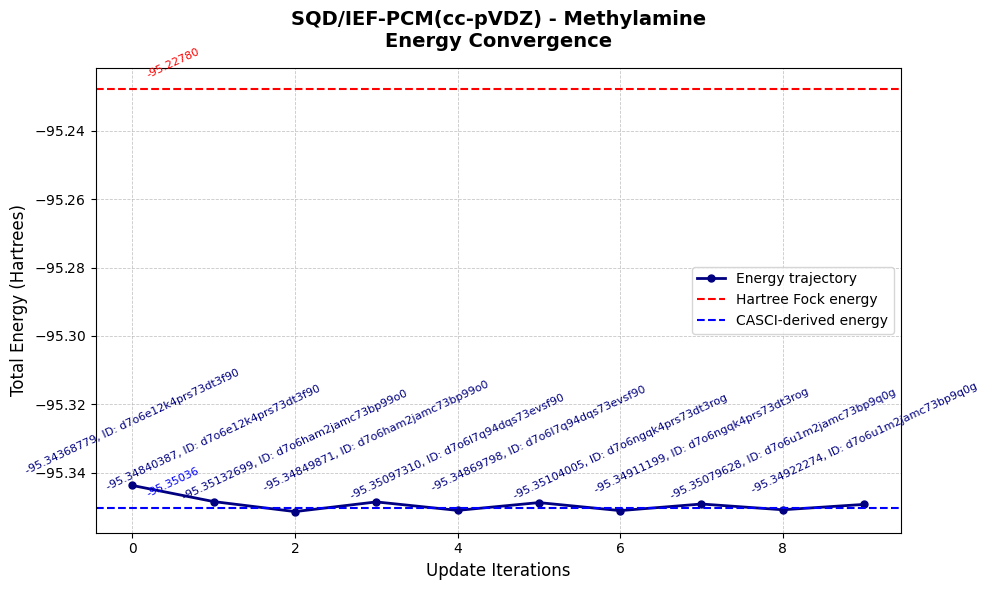

In [34]:
# Plot your data
import matplotlib.pyplot as plt
from utils.visualization import plot_data

fig, ax = plot_data(data, baseline_1=hf_e, baseline_2=CASCI_E, name=molecule_name, save=True)
plt.show()

In [ ]:
# Verify your data
print(f"Molecule: {molecule_name}")
print(f"Hartree-Fock Energy: {hf_e}")
print(f"CASCI Energy: {CASCI_E}")
print(f"Hardware Data:\n{data}")

Molecule: Methylamine
Hartree-Fock Energy: -95.2277952024392
CASCI Energy: -95.35035523972208
Hardware Data:
[(0, -95.34368779095594, 'd7o6e12k4prs73dt3f90'), (1, -95.34840386972695, 'd7o6e12k4prs73dt3f90'), (2, -95.35132698563851, 'd7o6ham2jamc73bp99o0'), (3, -95.34849870674013, 'd7o6ham2jamc73bp99o0'), (4, -95.35097310001336, 'd7o6l7q94dqs73evsf90'), (5, -95.34869798396727, 'd7o6l7q94dqs73evsf90'), (6, -95.35104005099046, 'd7o6ngqk4prs73dt3rog'), (7, -95.34911198576043, 'd7o6ngqk4prs73dt3rog'), (8, -95.35079628203417, 'd7o6u1m2jamc73bp9q0g'), (9, -95.34922274237286, 'd7o6u1m2jamc73bp9q0g')]
